In [75]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load Data

In [76]:
df_raw = df = pd.read_excel(r"C:\Users\Admin\OneDrive\Desktop\Data Analysis And Automation\Sample Data\online+retail+ii\online_retail_II.xlsx")
df = df_raw.copy()

Inspect Data

In [77]:
df.info()
df.head()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
count,525461.0,525461,522533,525461.000000,525461,525461.000000,417534.000000,525461
unique,28816.0,4632,4681,NaN,NaN,NaN,NaN,40
top,537434.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,675.0,3516,3549,NaN,NaN,NaN,NaN,485852
mean,NaN,NaN,NaN,10.337667,2010-06-28 11:37:36.845017856,4.688834,15360.645478,NaN
min,NaN,NaN,NaN,-9600.000000,2009-12-01 07:45:00,-53594.360000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2010-03-21 12:20:00,1.250000,13983.000000,NaN
50%,NaN,NaN,NaN,3.000000,2010-07-06 09:51:00,2.100000,15311.000000,NaN
75%,NaN,NaN,NaN,10.000000,2010-10-15 12:45:00,4.210000,16799.000000,NaN
max,NaN,NaN,NaN,19152.000000,2010-12-09 20:01:00,25111.090000,18287.000000,NaN


# Clean Data

In [78]:
df.isna().sum()

df = df.dropna(subset=["Customer ID"])
df['Description'] = df['Description'].fillna('Unknown')

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 417534 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      417534 non-null  object        
 1   StockCode    417534 non-null  object        
 2   Description  417534 non-null  object        
 3   Quantity     417534 non-null  int64         
 4   InvoiceDate  417534 non-null  datetime64[ns]
 5   Price        417534 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      417534 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 28.7+ MB


Fix Datatypes

In [79]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
df['Customer ID'] = df['Customer ID'].astype(str)



# Drop Invalid Records

In [80]:
df = df[df['Quantity']>0]
df = df[df['Price']>0]


Standadize text

In [81]:
df['Description'] = df['Description'].str.strip().str.lower()
df['Country'] = df['Country'].str.strip().str.title()

In [82]:
df = df.drop_duplicates()

df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15cm christmas glass ball 20 lights,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,pink cherry lights,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,white cherry lights,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"record frame 7"" single size",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,strawberry ceramic trinket box,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [83]:
df['total_price'] = df['Quantity'] * df['Price']
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day_name()

## The Analysis

In [84]:
monthly_sales = monthly_sales = df.groupby(['Year', 'Month'])['total_price'].sum().reset_index()

In [85]:
top_products = top_products = df.groupby('Description')['total_price'].sum().sort_values(ascending=False).head(10)

In [86]:
country_sales = country_sales = df.groupby('Country')['total_price'].sum().sort_values(ascending=False).head(10)

C:\Users\Admin\AppData\Local\Temp\ipykernel_1376\1038319004.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, ha='right')
C:\Users\Admin\AppData\Local\Temp\ipykernel_1376\1038319004.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_xticklabels(ax[2].get_xticklabels(), rotation=45, ha='right')


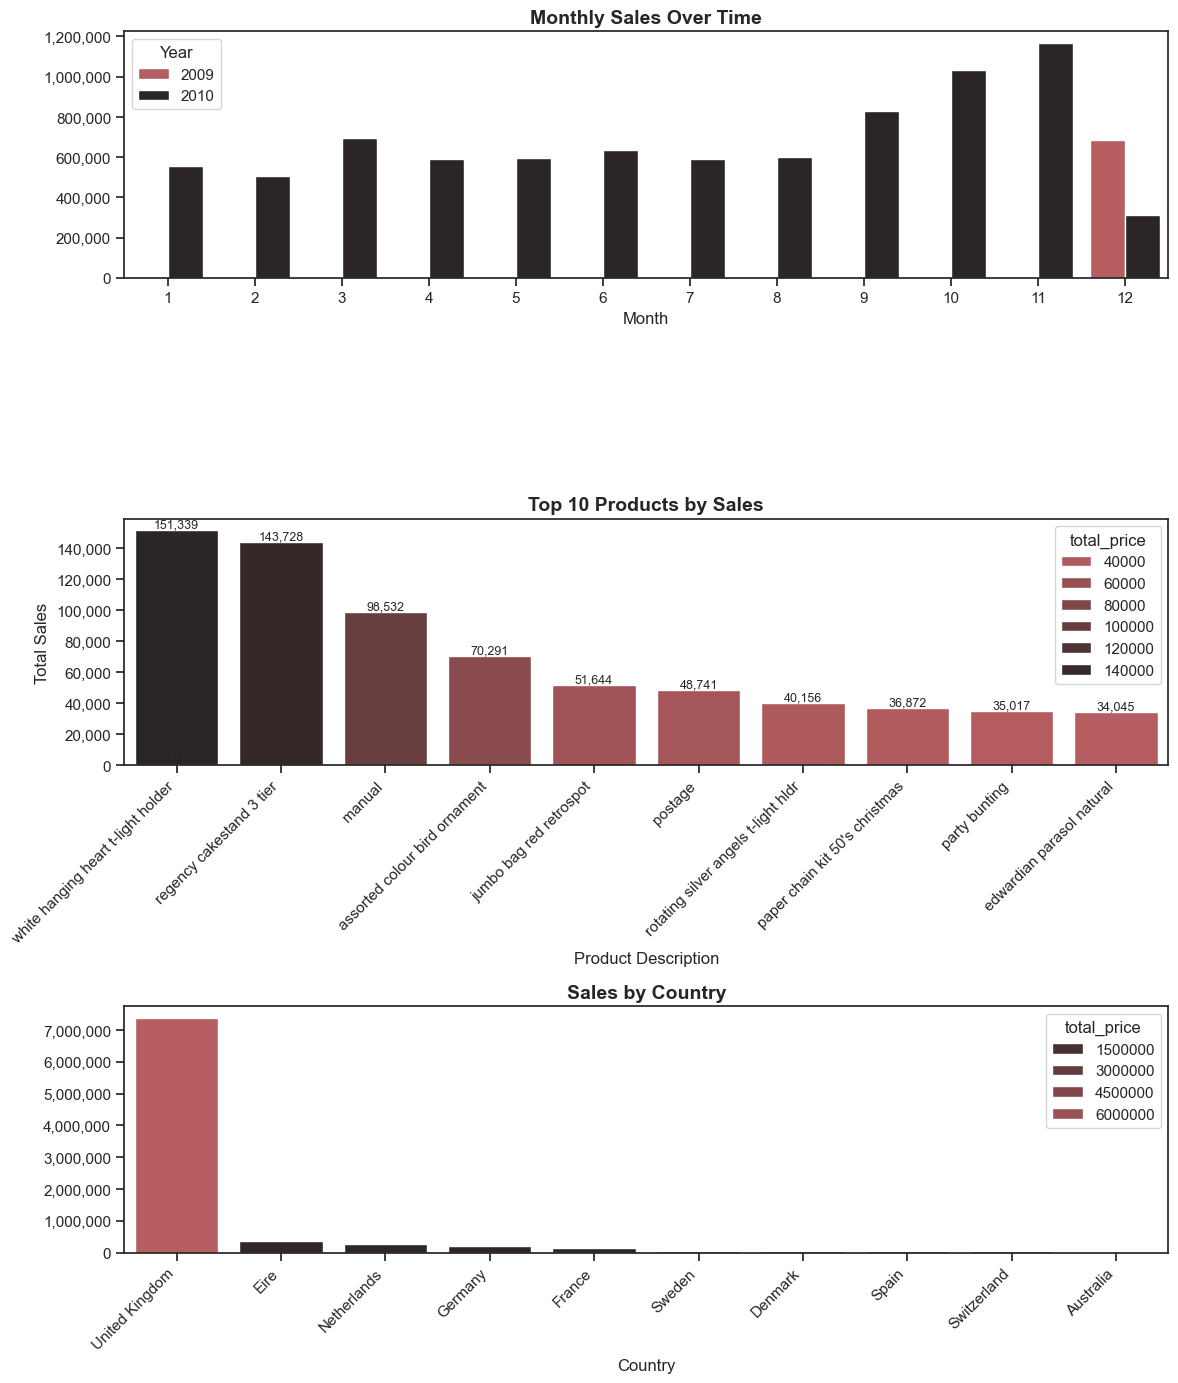

In [90]:
from matplotlib import ticker as mtick

fig, ax = plt.subplots(3, 1 , figsize=(12, 14))

sns.barplot(data=monthly_sales, x='Month', y='total_price', hue='Year', ax=ax[0], palette='dark:r_r')
ax[0].set_title('Monthly Sales Over Time', fontsize=14, fontweight='bold')
ax[0].set_ylabel('', fontsize=12)
ax[0].set_xlabel('Month', fontsize=12)
ax[0].yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax[0].legend(title='Year')

# Convert Series to DataFrame for plotting
top_products_df = top_products.reset_index()
country_sales_df = country_sales.reset_index()

sns.barplot(data=top_products_df, x='Description', y='total_price', ax=ax[1], hue='total_price', palette='dark:r_r')
ax[1].set_title('Top 10 Products by Sales', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Total Sales', fontsize=12)
ax[1].set_xlabel('Product Description' , fontsize=12)
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=45, ha='right')
ax[1].yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))


for p in ax[1].patches:
    ax[1].annotate(f'{p.get_height():,.0f}', 
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='bottom', fontsize=9, rotation=0)

sns.barplot(data=country_sales_df, x='Country', y='total_price', hue='total_price', ax=ax[2], palette='dark:r')
ax[2].set_title('Sales by Country', fontsize=14, fontweight='bold')
ax[2].set_ylabel('', fontsize=12)
ax[2].set_xlabel('Country', fontsize=12)
ax[2].set_xticklabels(ax[2].get_xticklabels(), rotation=45, ha='right')
ax[2].yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))



plt.tight_layout()